# Baseline Models: Linear Regression, Ridge, Huber & XGBoost

Comparative evaluation with expanded features, cross-sectional normalisation, recency weighting, and walk-forward validation.

## 1. Imports & Setup

In [89]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression, RidgeCV, HuberRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error
import xgboost as xgb
from dateutil.relativedelta import relativedelta
from tqdm import tqdm

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})


## 2. Configuration

In [90]:
BASE_DIR = Path('/Users/gabriel/Desktop/Sentiment Model')

# Target
RETURN_HORIZON = '21d'          # '1d' | '3d' | '5d' | '10d' | '21d'
TARGET_COL     = f'target_ret_{RETURN_HORIZON}'
HORIZON_DAYS   = int(RETURN_HORIZON.replace('d', ''))
ANN_FACTOR     = 252 / HORIZON_DAYS   # annualisation periods per year

# Date range
DATA_START = '2018-01-01'
DATA_END   = '2025-12-31'

# Walk-forward (expanding window)
TRAIN_YEARS = 2
TEST_YEARS  = 1

# Portfolio construction quantiles  (long top q%, short bottom q%)
PORT_QUANTILES = [0.20, 0.10, 0.05]

# Recency weighting
HALF_LIFE_YEARS = 2.0

# Market cap filter — number in $B (e.g. 2.0 = keep tickers >= $2B); None = all
MCAP_FILTER_B = 5.0

# PCA on dynamic features (STOCK + MARKET columns only; embeddings are excluded)
# Fit on training window, transform test — no look-ahead bias
USE_PCA       = True   # True | False
PCA_VARIANCE  = 0.98    # fraction of variance to retain (e.g. 0.95 = 95%)

# FNG regime bins
REGIME_BINS   = [0, 25, 45, 55, 75, 100]
REGIME_ORDER  = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
REGIME_COLORS = {
    'Extreme Fear':  '#d62728',
    'Fear':          '#ff7f0e',
    'Neutral':       '#aec7e8',
    'Greed':         '#2ca02c',
    'Extreme Greed': '#17becf',
}

print(f'Target       : {TARGET_COL}')
print(f'Ann factor   : {ANN_FACTOR:.2f}  (periods/year)')
print(f'Quantiles    : {PORT_QUANTILES}')
print(f'Half-life    : {HALF_LIFE_YEARS} years')
print(f'MCAP filter  : {"None (all tickers)" if MCAP_FILTER_B is None else f">= ${MCAP_FILTER_B}B"}')
print(f'PCA          : {"ON  (variance threshold=" + str(PCA_VARIANCE) + ")" if USE_PCA else "OFF"}')


Target       : target_ret_21d
Ann factor   : 12.00  (periods/year)
Quantiles    : [0.2, 0.1, 0.05]
Half-life    : 2.0 years
MCAP filter  : >= $5.0B
PCA          : ON  (variance threshold=0.98)


## 3. Data Loading

In [91]:
# ── 3a. Stock features (59 parquet batches) ──────────────────────────────────
STOCK_COLS = [
    'date', 'ticker',
    # Momentum (multi-scale)
    'roc_5', 'roc_21', 'roc_63',
    # Volatility (multi-scale + regime)
    'vol_std_21', 'vol_std_63', 'vol_std_zscore_21',
    'atr_21_pct_close',
    # RSI (mean-reversion)
    'rsi_21', 'rsi_63',
    # EMA trend signals
    'ema5_above_ema21', 'ema21_above_ema63',
    'dist_to_ema_21_pct', 'dist_to_ema_63_pct',
    # Volume / liquidity
    'vol_zscore_21', 'vol_ratio_21',
    # Beta (factor exposures)
    'beta_spy', 'beta_tlt', 'beta_^vix', 'beta_sphb', 'beta_splv',
    # Stochastic
    'stoch_k_21',
    # Calendar
    'dow_1', 'dow_2', 'dow_3', 'dow_4',
    # Targets
    'target_ret_1d', 'target_ret_3d', 'target_ret_5d',
    'target_ret_10d', 'target_ret_21d',
]

parquet_dir = BASE_DIR / 'stock_training_data_final'
batches     = sorted(parquet_dir.glob('batch_*.parquet'))
print(f'Loading {len(batches)} parquet batches ...')

stock_df = pd.concat(
    [pd.read_parquet(p, columns=STOCK_COLS) for p in tqdm(batches)],
    ignore_index=True
)

if stock_df['date'].dt.tz is not None:
    stock_df['date'] = stock_df['date'].dt.tz_localize(None)
stock_df['date'] = pd.to_datetime(stock_df['date']).dt.normalize()
print(f'Stock data: {stock_df.shape}  |  {stock_df["date"].min().date()} - {stock_df["date"].max().date()}')

Loading 59 parquet batches ...


100%|██████████| 59/59 [00:01<00:00, 32.52it/s]


Stock data: (4756938, 32)  |  2018-07-23 - 2025-12-17


In [92]:
# ── 3b. Market / macro features ───────────────────────────────────────────────
MKT_COLS = [
    # Volatility regime
    'vix', 'vix_zscore_21', 'egarch_vol',
    # SPX trend
    'spx_dist_to_ma200', 'spx_mom_3m', 'spx_drawdown',
    # Yield curve
    'yield_10y_3m', 'yield_30y_10y',
    # Credit / risk appetite
    'credit_spread_mom_1m', 'hyg_tlt_ratio_mom_1m',
    # Breadth / rotation
    'rsp_spy_spread_1m', 'cyclical_defensive_spread_1m',
    # FNG sentiment
    'fear_greed',
    'fng_q2_fear', 'fng_q3_neutral', 'fng_q4_greed', 'fng_q5_extreme_greed',
    'fng_diff_5',
]

mkt_path = BASE_DIR / 'market_training_data_final' / 'market_state_vector.parquet'
mkt_df   = pd.read_parquet(mkt_path, columns=MKT_COLS).reset_index()
mkt_df   = mkt_df.rename(columns={mkt_df.columns[0]: 'date'})

if mkt_df['date'].dt.tz is not None:
    mkt_df['date'] = mkt_df['date'].dt.tz_localize(None)
mkt_df['date'] = pd.to_datetime(mkt_df['date']).dt.normalize()

# Build a date-indexed FNG regime series for regime colouring
fng_regime_series = pd.cut(
    mkt_df.set_index('date')['fear_greed'],
    bins=REGIME_BINS, labels=REGIME_ORDER
)

print(f'Market data: {mkt_df.shape}  |  {mkt_df["date"].min().date()} - {mkt_df["date"].max().date()}')

Market data: (3547, 19)  |  2012-01-04 - 2026-02-13


In [93]:
# ── 3c. Static ticker embeddings & market cap ─────────────────────────────────
EMB_COLS = (
    ['ticker']
    + [f'sector_emb_{i}'   for i in range(6)]
    + [f'industry_emb_{i}' for i in range(16)]
    + [f'country_emb_{i}'  for i in range(8)]
    + ['mcap_small', 'mcap_mid', 'mcap_large', 'mcap_mega']
)
emb_df = pd.read_csv(BASE_DIR / 'stock_market_features.csv', usecols=EMB_COLS)

# Load actual market cap ($) for the MCAP_FILTER_B threshold
mcap_df = (
    pd.read_csv(BASE_DIR / 'us_stocks_500m.csv', usecols=['ticker', 'market_cap'])
    .drop_duplicates('ticker')
)
mcap_df['market_cap_b'] = mcap_df['market_cap'] / 1e9
emb_df = emb_df.merge(mcap_df[['ticker', 'market_cap_b']], on='ticker', how='left')

print(f'Embeddings : {emb_df.shape}  |  market_cap_b present: {emb_df["market_cap_b"].notna().sum():,}')


Embeddings : (3098, 36)  |  market_cap_b present: 3,098


In [94]:
# ── 3d. Merge & filter ────────────────────────────────────────────────────────
df = (
    stock_df
    .merge(mkt_df, on='date', how='left')
    .merge(emb_df, on='ticker', how='left')
)

df = df[(df['date'] >= DATA_START) & (df['date'] <= DATA_END)].copy()

core_required = ['roc_21', 'vol_std_21', 'beta_spy', 'fear_greed', TARGET_COL]
df.dropna(subset=core_required, inplace=True)

# Market cap filter
if MCAP_FILTER_B is not None:
    before = df['ticker'].nunique()
    df = df[df['market_cap_b'] >= MCAP_FILTER_B].copy()
    after = df['ticker'].nunique()
    print(f'MCAP filter >= ${MCAP_FILTER_B}B: {before:,} -> {after:,} tickers')

df.reset_index(drop=True, inplace=True)

# Attach fng_regime label
df['fng_regime'] = pd.cut(df['fear_greed'], bins=REGIME_BINS,
                           labels=REGIME_ORDER, include_lowest=True)

print(f'Merged dataset : {df.shape}')
print(f'Date range     : {df["date"].min().date()} - {df["date"].max().date()}')
print(f'Unique tickers : {df["ticker"].nunique():,}')


MCAP filter >= $5.0B: 2,908 -> 1,321 tickers
Merged dataset : (2237889, 86)
Date range     : 2018-07-23 - 2025-11-17
Unique tickers : 1,321


## 4. Feature Definitions

In [95]:
STOCK_FEATURES = [
    'roc_5', 'roc_21', 'roc_63',
    'vol_std_21', 'vol_std_63', 'vol_std_zscore_21',
    'atr_21_pct_close',
    'rsi_21', 'rsi_63',
    'ema5_above_ema21', 'ema21_above_ema63',
    'dist_to_ema_21_pct', 'dist_to_ema_63_pct',
    'vol_zscore_21', 'vol_ratio_21',
    'beta_spy', 'beta_tlt', 'beta_^vix', 'beta_sphb', 'beta_splv',
    'stoch_k_21',
    'dow_1', 'dow_2', 'dow_3', 'dow_4',
]

MARKET_FEATURES = [
    'vix', 'vix_zscore_21', 'egarch_vol',
    'spx_dist_to_ma200', 'spx_mom_3m', 'spx_drawdown',
    'yield_10y_3m', 'yield_30y_10y',
    'credit_spread_mom_1m', 'hyg_tlt_ratio_mom_1m',
    'rsp_spy_spread_1m', 'cyclical_defensive_spread_1m',
    'fear_greed',
    'fng_q1_extreme_fear','fng_q2_fear', 'fng_q4_greed', 'fng_q5_extreme_greed',
    'fng_diff_5',
]

SECTOR_FEATURES = [f'sector_emb_{i}'   for i in range(6)]
IND_FEATURES    = [f'industry_emb_{i}' for i in range(16)]
CTRY_FEATURES   = [f'country_emb_{i}'  for i in range(8)]
MCAP_FEATURES   = ['mcap_small', 'mcap_mid', 'mcap_large', 'mcap_mega']

FEATURE_COLS = (
    STOCK_FEATURES + MARKET_FEATURES
    + SECTOR_FEATURES + IND_FEATURES + CTRY_FEATURES + MCAP_FEATURES
)
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

print(f'Total features  : {len(FEATURE_COLS)}')
print(f'  Stock         : {len([c for c in STOCK_FEATURES   if c in df.columns])}')
print(f'  Market        : {len([c for c in MARKET_FEATURES  if c in df.columns])}')
print(f'  Embeddings    : {len([c for c in SECTOR_FEATURES+IND_FEATURES+CTRY_FEATURES+MCAP_FEATURES if c in df.columns])}')

Total features  : 76
  Stock         : 25
  Market        : 17
  Embeddings    : 34


## 5. EDA

In [96]:
# ── 5a. Summary stats ────────────────────────────────────────────���───────────
print(f'Rows: {len(df):,}  |  Dates: {df["date"].nunique():,}  |  Tickers: {df["ticker"].nunique():,}')
print(f'Features: {len(FEATURE_COLS)}  |  Target: {TARGET_COL}')
print()
print(df[TARGET_COL].describe().to_string())

Rows: 2,237,889  |  Dates: 1,842  |  Tickers: 1,321
Features: 76  |  Target: target_ret_21d

count   2237889.0000
mean          0.0089
std           0.1214
min          -2.3458
25%          -0.0461
50%           0.0119
75%           0.0676
max           6.0700


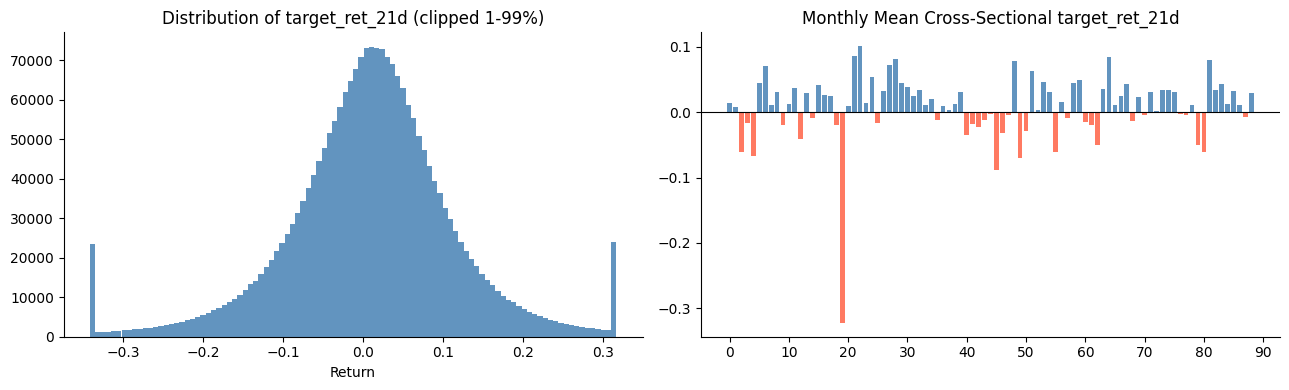

In [97]:
# ── 5b. Target distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

lo, hi = df[TARGET_COL].quantile(0.01), df[TARGET_COL].quantile(0.99)
axes[0].hist(df[TARGET_COL].clip(lo, hi), bins=100,
             color='steelblue', edgecolor='none', alpha=0.85)
axes[0].set_title(f'Distribution of {TARGET_COL} (clipped 1-99%)')
axes[0].set_xlabel('Return')

monthly = df.groupby(df['date'].dt.to_period('M'))[TARGET_COL].mean()
axes[1].bar(range(len(monthly)), monthly.values,
            color=['tomato' if v < 0 else 'steelblue' for v in monthly.values],
            edgecolor='none', alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title(f'Monthly Mean Cross-Sectional {TARGET_COL}')
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(10))

plt.tight_layout(); plt.show()

In [98]:
# ── 5c. Feature IC vs target (Spearman) ──────────────────────────────────────
ic_rows = []
for col in STOCK_FEATURES + ['fear_greed', 'vix', 'spx_mom_3m']:
    if col not in df.columns:
        continue
    rho, pval = spearmanr(df[col].fillna(0), df[TARGET_COL])
    ic_rows.append({'Feature': col, 'Spearman IC': round(rho, 5), 'p-value': round(pval, 4)})

ic_df = pd.DataFrame(ic_rows).sort_values('Spearman IC', key=abs, ascending=False)
print('=== Unconditional Spearman IC ===')
print(ic_df.to_string(index=False))

=== Unconditional Spearman IC ===
           Feature  Spearman IC  p-value
               vix       0.1179   0.0000
  atr_21_pct_close       0.0900   0.0000
        vol_std_63       0.0885   0.0000
         beta_^vix      -0.0809   0.0000
        vol_std_21       0.0809   0.0000
         beta_splv       0.0735   0.0000
        spx_mom_3m      -0.0712   0.0000
        fear_greed      -0.0712   0.0000
            rsi_63      -0.0600   0.0000
dist_to_ema_63_pct      -0.0535   0.0000
            rsi_21      -0.0532   0.0000
 ema21_above_ema63      -0.0532   0.0000
            roc_63      -0.0457   0.0000
            roc_21      -0.0454   0.0000
  ema5_above_ema21      -0.0445   0.0000
dist_to_ema_21_pct      -0.0391   0.0000
         beta_sphb       0.0387   0.0000
        stoch_k_21      -0.0376   0.0000
 vol_std_zscore_21       0.0373   0.0000
          beta_spy       0.0344   0.0000
          beta_tlt      -0.0238   0.0000
             roc_5      -0.0191   0.0000
     vol_zscore_21     

=== Mean Return by FNG Regime ===
               Mean Return  Std Dev       N
fng_regime                                 
Extreme Fear        0.0169   0.1368  346299
Fear                0.0173   0.1224  596248
Neutral            -0.0005   0.1280  365819
Greed               0.0033   0.1137  785998
Extreme Greed       0.0093   0.0945  143525


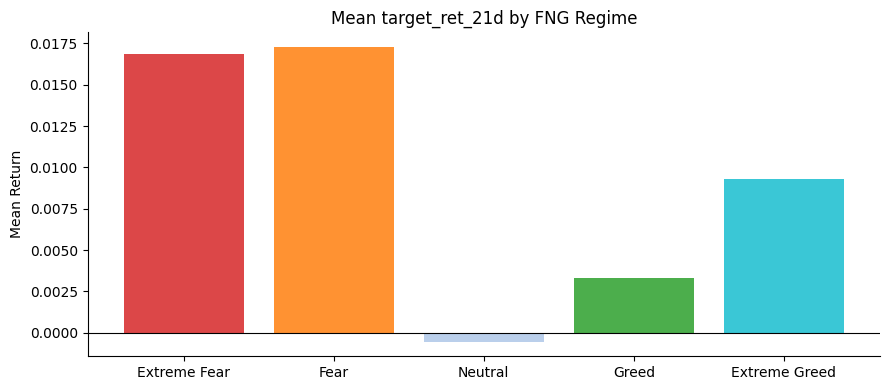

In [99]:
# ── 5d. Mean return by FNG regime ────────────────────────────────────────────
regime_stats = df.groupby('fng_regime')[TARGET_COL].agg(['mean', 'std', 'count'])
regime_stats.columns = ['Mean Return', 'Std Dev', 'N']
print('=== Mean Return by FNG Regime ===')
print(regime_stats.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
colors = [REGIME_COLORS[r] for r in REGIME_ORDER]
ax.bar(REGIME_ORDER, regime_stats.reindex(REGIME_ORDER)['Mean Return'].values,
       color=colors, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title(f'Mean {TARGET_COL} by FNG Regime')
ax.set_ylabel('Mean Return')
plt.tight_layout(); plt.show()

## 6. Walk-Forward Folds

In [100]:
def generate_wf_folds(start_year, end_year, min_train_years, test_years, step_years=1):
    """Expanding-window walk-forward. Training always anchored at start_year."""
    folds = []
    test_start = pd.Timestamp(f'{start_year + min_train_years}-01-01')
    while True:
        train_start = pd.Timestamp(f'{start_year}-01-01')
        train_end   = test_start - pd.Timedelta(days=1)
        test_end    = test_start + relativedelta(years=test_years) - pd.Timedelta(days=1)
        if test_end.year > end_year:
            break
        label = f'Train {train_start.year}-{train_end.year} | Test {test_start.year}'
        folds.append((label, train_start, train_end, test_start, test_end))
        test_start += relativedelta(years=step_years)
    return folds

WF_FOLDS = generate_wf_folds(
    start_year=2018, end_year=2025,
    min_train_years=TRAIN_YEARS, test_years=TEST_YEARS, step_years=1
)

print('Walk-forward folds:')
for name, tr_s, tr_e, te_s, te_e in WF_FOLDS:
    print(f'  {name}  [{(te_s - tr_s).days // 365}yr train]')


Walk-forward folds:
  Train 2018-2019 | Test 2020  [2yr train]
  Train 2018-2020 | Test 2021  [3yr train]
  Train 2018-2021 | Test 2022  [4yr train]
  Train 2018-2022 | Test 2023  [5yr train]
  Train 2018-2023 | Test 2024  [6yr train]
  Train 2018-2024 | Test 2025  [7yr train]


## 7. Preprocessing Functions

In [101]:
def make_recency_weights(dates, half_life_years=HALF_LIFE_YEARS):
    """Exponential decay: each observation loses half its weight every half_life_years."""
    d = pd.to_datetime(dates)
    days_ago = (d.max() - d).dt.days.values.astype(np.float32)
    half_life_days = half_life_years * 365.25
    return np.exp(-np.log(2) * days_ago / half_life_days)


def slice_fold(df, train_start, train_end, test_start, test_end):
    """
    Split data into train/test, apply preprocessing, return arrays.

    Preprocessing:
      - Stock features   : per-date cross-sectional z-score (each date independently)
      - Market features  : StandardScaler fitted on train only
      - PCA (optional)   : applied to dynamic features (stock + market) after scaling,
                           fit on train only; embeddings passed through unchanged
      - Recency weights  : exponential decay on train dates
    """
    train = (df[(df['date'] >= train_start) & (df['date'] <= train_end)]
             .dropna(subset=FEATURE_COLS + [TARGET_COL])
             .copy())
    test  = (df[(df['date'] >= test_start)  & (df['date'] <= test_end)]
             .dropna(subset=FEATURE_COLS + [TARGET_COL])
             .copy())

    if len(train) < 1000 or len(test) < 100:
        return None

    # CS z-score for stock features (per date, no cross-period leakage)
    stock_feat_present = [c for c in STOCK_FEATURES if c in train.columns]
    for col in stock_feat_present:
        train[col] = train.groupby('date')[col].transform(
            lambda x: (x - x.mean()) / (x.std() + 1e-8))
        test[col]  = test.groupby('date')[col].transform(
            lambda x: (x - x.mean()) / (x.std() + 1e-8))

    # Global scaler for market + embedding features (fit on train only)
    non_stock = [c for c in FEATURE_COLS
                 if c not in STOCK_FEATURES and c in train.columns]
    if non_stock:
        scaler = StandardScaler()
        train[non_stock] = scaler.fit_transform(train[non_stock])
        test[non_stock]  = scaler.transform(test[non_stock])

    weights = make_recency_weights(train['date'])

    X_train = train[FEATURE_COLS].values.astype(np.float32)
    X_test  = test[FEATURE_COLS].values.astype(np.float32)
    y_train = train[TARGET_COL].values.astype(np.float32)
    y_test  = test[TARGET_COL].values.astype(np.float32)

    # PCA on dynamic features only (stock + market), embeddings pass through
    if USE_PCA:
        EMBED_FEATURES = (
            [f'sector_emb_{i}'   for i in range(6)]
            + [f'industry_emb_{i}' for i in range(16)]
            + [f'country_emb_{i}'  for i in range(8)]
            + ['mcap_small', 'mcap_mid', 'mcap_large', 'mcap_mega']
        )
        feat_arr  = np.array(FEATURE_COLS)
        dyn_idx   = np.array([i for i, c in enumerate(FEATURE_COLS)
                               if c not in EMBED_FEATURES])
        emb_idx   = np.array([i for i, c in enumerate(FEATURE_COLS)
                               if c in EMBED_FEATURES])

        pca = PCA(n_components=PCA_VARIANCE, svd_solver='full')
        X_train_dyn = pca.fit_transform(X_train[:, dyn_idx])
        X_test_dyn  = pca.transform(X_test[:, dyn_idx])
        print(f'    PCA: {pca.n_components_} components -> {PCA_VARIANCE*100:.0f}% variance (from {len(dyn_idx)} dynamic features)')

        X_train_emb = X_train[:, emb_idx] if len(emb_idx) > 0 else np.empty((len(X_train), 0))
        X_test_emb  = X_test[:, emb_idx]  if len(emb_idx) > 0 else np.empty((len(X_test),  0))

        X_train = np.concatenate([X_train_dyn, X_train_emb], axis=1).astype(np.float32)
        X_test  = np.concatenate([X_test_dyn,  X_test_emb],  axis=1).astype(np.float32)

    return (X_train, y_train, X_test, y_test,
            test['date'].values, test['ticker'].values, weights)


## 8. Model Training Functions

In [102]:
def train_linear(X_train, y_train, weights):
    model = LinearRegression()
    model.fit(X_train, y_train, sample_weight=weights)
    return model

def train_ridge(X_train, y_train, weights):
    model = RidgeCV(alphas=[1.0, 10.0, 100.0, 1000.0], cv=5)
    model.fit(X_train, y_train, sample_weight=weights)
    print(f'    Ridge best alpha: {model.alpha_:.4f}')
    return model

def train_huber(X_train, y_train, weights):
    # lbfgs requires float64; large folds need more iterations
    model = HuberRegressor(epsilon=1.35, max_iter=2000, alpha=0.01, tol=1e-4)
    model.fit(X_train.astype(np.float64), y_train.astype(np.float64),
              sample_weight=weights.astype(np.float64))
    return model

def train_xgboost(X_train, y_train, weights):
    model = xgb.XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=50,
        gamma=1.0, reg_alpha=0.1, reg_lambda=1.0,
        objective='reg:squarederror', tree_method='hist',
        n_jobs=-1, random_state=42, verbosity=0,
    )
    model.fit(X_train, y_train, sample_weight=weights)
    return model

MODELS = {
    'LinearReg': train_linear,
    'Ridge':     train_ridge,
    'Huber':     train_huber,
    'XGBoost':   train_xgboost,
}

print('Models registered:', list(MODELS.keys()))

Models registered: ['LinearReg', 'Ridge', 'Huber', 'XGBoost']


## 9. Evaluation Functions

In [103]:
def compute_ic_metrics(y_true, y_pred, dates, tickers):
    """IC, ICIR, hit rate, R2, RMSE."""
    ic_global, _ = spearmanr(y_pred, y_true)

    results_df = pd.DataFrame({
        'date': dates, 'ticker': tickers,
        'y_true': y_true, 'y_pred': y_pred
    })

    daily_ic = (
        results_df.groupby('date')
        .apply(lambda g: spearmanr(g['y_pred'], g['y_true'])[0] if len(g) >= 5 else np.nan)
        .dropna()
    )

    mean_ic = daily_ic.mean()
    icir    = mean_ic / daily_ic.std() if daily_ic.std() > 0 else np.nan
    hit_rate = np.mean(np.sign(y_pred) == np.sign(y_true))

    return {
        'IC (global)':   ic_global,
        'Mean Daily IC': mean_ic,
        'ICIR':          icir,
        'Hit Rate':      hit_rate,
        'R2':            r2_score(y_true, y_pred),
        'RMSE':          np.sqrt(mean_squared_error(y_true, y_pred)),
        '_daily_ic':     daily_ic,
        '_df':           results_df,
    }


def compute_ls_returns(preds_df, quantile, min_stocks=10):
    """
    For each date rank stocks by y_pred.
    Return a Series of daily L/S returns (long top q%, short bottom q%).
    Also returns long-only and short-only series for decomposition.
    """
    records = []
    for date, g in preds_df.groupby('date'):
        n = len(g)
        if n < min_stocks:
            continue
        n_port = max(1, int(np.ceil(n * quantile)))
        ranked    = g.sort_values('y_pred')
        long_ret  = ranked.iloc[-n_port:]['y_true'].mean()
        short_ret = ranked.iloc[:n_port]['y_true'].mean()
        records.append({
            'date':      date,
            'ls_ret':    long_ret - short_ret,
            'long_ret':  long_ret,
            'short_ret': short_ret,
            'n':         n,
        })
    return pd.DataFrame(records).set_index('date').sort_index()


def compute_strategy_metrics(ls_series):
    """
    Annualised return, vol, Sharpe, Sortino, Calmar, max drawdown, win rate.
    Uses ANN_FACTOR = 252 / HORIZON_DAYS so that e.g. 21d returns are scaled by 12.
    Note: overlapping windows inflate effective sample size; treat as signal-strength
    comparison rather than realised live Sharpe.
    """
    s = ls_series.dropna()
    if len(s) < 20:
        return {k: np.nan for k in
                ['Ann. Return', 'Ann. Vol', 'Sharpe', 'Sortino',
                 'Calmar', 'Max DD', 'Win Rate']}

    ann_ret = s.mean() * ANN_FACTOR
    ann_vol = s.std()  * np.sqrt(ANN_FACTOR)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan

    downside = s[s < 0].std() * np.sqrt(ANN_FACTOR)
    sortino  = ann_ret / downside if downside > 0 else np.nan

    cum      = (1 + s).cumprod()
    max_dd   = ((cum - cum.cummax()) / cum.cummax()).min()
    calmar   = ann_ret / abs(max_dd) if max_dd < 0 else np.nan

    return {
        'Ann. Return': ann_ret,
        'Ann. Vol':    ann_vol,
        'Sharpe':      sharpe,
        'Sortino':     sortino,
        'Calmar':      calmar,
        'Max DD':      max_dd,
        'Win Rate':    (s > 0).mean(),
    }

## 10. Walk-Forward Training

In [104]:
# Storage: model_name -> list of prediction DataFrames (one per fold)
wf_preds   = {m: [] for m in MODELS}
wf_results = []         # flat list of dicts for summary table
xgb_imps   = {}         # fold_name -> feature importances
lin_coefs  = {}         # fold_name -> {model_name -> coef array}

for fold in WF_FOLDS:
    fold_name, tr_s, tr_e, te_s, te_e = fold
    print(f'\n── {fold_name} ──')

    result = slice_fold(df, tr_s, tr_e, te_s, te_e)
    if result is None:
        print('  Insufficient data — skipping.')
        continue

    X_train, y_train, X_test, y_test, te_dates, te_tickers, weights = result
    print(f'  Train: {len(X_train):,}  |  Test: {len(X_test):,}')

    coefs_this_fold = {}

    for model_name, train_fn in MODELS.items():
        print(f'  [{model_name}]', end='  ')
        model = train_fn(X_train, y_train, weights)
        y_pred = model.predict(X_test)

        pred_df = pd.DataFrame({
            'date':   te_dates,
            'ticker': te_tickers,
            'y_pred': y_pred,
            'y_true': y_test,
        })
        wf_preds[model_name].append(pred_df)

        metrics = compute_ic_metrics(y_test, y_pred, te_dates, te_tickers)
        wf_results.append({
            'Model': model_name, 'Fold': fold_name,
            **{k: v for k, v in metrics.items() if not k.startswith('_')}
        })

        print(f'IC={metrics["Mean Daily IC"]:.4f}  ICIR={metrics["ICIR"]:.3f}')

        # Store feature info (only valid when PCA is off — components don't map back to features)
        if not USE_PCA:
            if model_name == 'XGBoost':
                xgb_imps[fold_name] = pd.Series(model.feature_importances_, index=FEATURE_COLS)
            if hasattr(model, 'coef_'):
                coefs_this_fold[model_name] = model.coef_

    lin_coefs[fold_name] = coefs_this_fold

# Concatenate walk-forward predictions per model
wf_combined = {m: pd.concat(wf_preds[m]).reset_index(drop=True)
               for m in MODELS if wf_preds[m]}

print('\nWalk-forward training complete.')
print({m: len(v) for m, v in wf_combined.items()}, 'rows per model')


── Train 2018-2019 | Test 2020 ──
  Train: 404,280  |  Test: 291,444
  [LinearReg]  IC=0.0843  ICIR=0.675
  [Ridge]      Ridge best alpha: 1000.0000
IC=0.0845  ICIR=0.675
  [Huber]  IC=0.1008  ICIR=0.851
  [XGBoost]  IC=0.0535  ICIR=0.267

── Train 2018-2020 | Test 2021 ──
  Train: 695,724  |  Test: 301,984
  [LinearReg]  IC=-0.0155  ICIR=-0.064
  [Ridge]      Ridge best alpha: 1000.0000
IC=-0.0157  ICIR=-0.065
  [Huber]  IC=-0.0005  ICIR=-0.002
  [XGBoost]  IC=-0.0154  ICIR=-0.096

── Train 2018-2021 | Test 2022 ──
  Train: 997,708  |  Test: 313,012
  [LinearReg]  IC=0.0019  ICIR=0.012
  [Ridge]      Ridge best alpha: 1000.0000
IC=0.0018  ICIR=0.011
  [Huber]  IC=-0.0227  ICIR=-0.111
  [XGBoost]  IC=0.0408  ICIR=0.284

── Train 2018-2022 | Test 2023 ──
  Train: 1,310,720  |  Test: 316,054
  [LinearReg]  IC=-0.0113  ICIR=-0.077
  [Ridge]      Ridge best alpha: 1000.0000
IC=-0.0120  ICIR=-0.086
  [Huber]  IC=0.0060  ICIR=0.057
  [XGBoost]  IC=0.0036  ICIR=0.025

── Train 2018-2023 | Te

## 12. Analysis

All analysis functions are defined here then applied to walk-forward combined, large fold, and 2025 fold.

In [105]:
# ── 12a. IC Summary Table ─────────────────────────────────────────────────────
wf_df = pd.DataFrame(wf_results)
display_cols = ['Model', 'Fold', 'Mean Daily IC', 'ICIR', 'Hit Rate', 'R2', 'RMSE']

print('=== Walk-Forward IC Summary ===')
print(wf_df[display_cols].to_string(index=False))

print('\n=== Walk-Forward Averages by Model ===')
avg = wf_df.groupby('Model')[['Mean Daily IC', 'ICIR', 'Hit Rate', 'R2']].mean()
print(avg.round(4).to_string())


=== Walk-Forward IC Summary ===
    Model                        Fold  Mean Daily IC    ICIR  Hit Rate      R2   RMSE
LinearReg Train 2018-2019 | Test 2020         0.0843  0.6749    0.5799 -0.0266 0.1887
    Ridge Train 2018-2019 | Test 2020         0.0845  0.6752    0.5799 -0.0256 0.1886
    Huber Train 2018-2019 | Test 2020         0.1008  0.8510    0.5804 -0.0199 0.1881
  XGBoost Train 2018-2019 | Test 2020         0.0535  0.2667    0.5832  0.0102 0.1853
LinearReg Train 2018-2020 | Test 2021        -0.0155 -0.0643    0.5604 -0.1345 0.1081
    Ridge Train 2018-2020 | Test 2021        -0.0157 -0.0649    0.5603 -0.1339 0.1081
    Huber Train 2018-2020 | Test 2021        -0.0005 -0.0023    0.5685 -0.0244 0.1027
  XGBoost Train 2018-2020 | Test 2021        -0.0154 -0.0957    0.5203 -0.2645 0.1142
LinearReg Train 2018-2021 | Test 2022         0.0019  0.0119    0.5109 -0.0816 0.1332
    Ridge Train 2018-2021 | Test 2022         0.0018  0.0114    0.5107 -0.0815 0.1332
    Huber Train 2018-2

In [106]:
# ── 12b. L/S Strategy Metrics Table ──────────────────────────────────────────
def build_strategy_table(preds_dict, label):
    rows = []
    for model_name, pred_df in preds_dict.items():
        for q in PORT_QUANTILES:
            ls = compute_ls_returns(pred_df, q)['ls_ret']
            m  = compute_strategy_metrics(ls)
            rows.append({'Dataset': label, 'Model': model_name,
                         'Quantile': f'Top/Bot {int(q*100)}%', **m})
    return pd.DataFrame(rows)

strat_wf  = build_strategy_table(wf_combined, 'WF Combined')
strat_all = strat_wf.copy()

metric_cols = ['Ann. Return', 'Ann. Vol', 'Sharpe', 'Sortino', 'Calmar', 'Max DD', 'Win Rate']
print('=== L/S Strategy Metrics (Walk-Forward Combined) ===')
print(strat_all.set_index(['Dataset', 'Model', 'Quantile'])[metric_cols].round(3).to_string())


=== L/S Strategy Metrics (Walk-Forward Combined) ===
                                   Ann. Return  Ann. Vol  Sharpe  Sortino  Calmar  Max DD  Win Rate
Dataset     Model     Quantile                                                                     
WF Combined LinearReg Top/Bot 20%       0.0650    0.1810  0.3590   0.6010  0.0650 -1.0000    0.5490
                      Top/Bot 10%       0.0850    0.2400  0.3530   0.6100  0.0850 -1.0000    0.5390
                      Top/Bot 5%        0.1160    0.3130  0.3720   0.6820  0.1160 -1.0000    0.5490
            Ridge     Top/Bot 20%       0.0680    0.1820  0.3740   0.6020  0.0680 -1.0000    0.5500
                      Top/Bot 10%       0.0910    0.2430  0.3760   0.6340  0.0910 -1.0000    0.5380
                      Top/Bot 5%        0.1210    0.3190  0.3790   0.6910  0.1210 -1.0000    0.5430
            Huber     Top/Bot 20%       0.0630    0.1750  0.3630   0.5760  0.0640 -0.9990    0.5530
                      Top/Bot 10%       0.0760 

In [107]:
# ── 12b-ii. Long-Only Strategy Metrics ───────────────────────────────────────
def build_longonly_table(preds_dict, label):
    rows = []
    for model_name, pred_df in preds_dict.items():
        for q in PORT_QUANTILES:
            ls_df = compute_ls_returns(pred_df, q)
            long_s = ls_df['long_ret']
            m = compute_strategy_metrics(long_s)
            rows.append({'Dataset': label, 'Model': model_name,
                         'Quantile': f'Top {int(q*100)}%', **m})
    return pd.DataFrame(rows)

longonly_wf  = build_longonly_table(wf_combined, 'WF Combined')

print('=== Long-Only Strategy Metrics (Walk-Forward Combined) ===')
print(longonly_wf.set_index(['Dataset', 'Model', 'Quantile'])[metric_cols].round(3).to_string())


=== Long-Only Strategy Metrics (Walk-Forward Combined) ===
                                Ann. Return  Ann. Vol  Sharpe  Sortino  Calmar  Max DD  Win Rate
Dataset     Model     Quantile                                                                  
WF Combined LinearReg Top 20%        0.1540    0.2600  0.5940   0.7190  0.1540 -1.0000    0.6130
                      Top 10%        0.1700    0.2860  0.5950   0.7880  0.1700 -1.0000    0.6090
                      Top 5%         0.1930    0.3230  0.5980   0.8620  0.1930 -1.0000    0.6000
            Ridge     Top 20%        0.1590    0.2610  0.6090   0.7400  0.1590 -1.0000    0.6120
                      Top 10%        0.1800    0.2890  0.6210   0.8290  0.1800 -1.0000    0.6070
                      Top 5%         0.2020    0.3290  0.6160   0.8980  0.2020 -1.0000    0.5990
            Huber     Top 20%        0.1530    0.2740  0.5590   0.6790  0.1530 -1.0000    0.6010
                      Top 10%        0.1630    0.2970  0.5480   0.72

In [108]:
# ── 12b-iii. Monthly L / S / L-S Return Table ────────────────────────────────
# Uses last trading day of each month so consecutive rows are ~non-overlapping
# (21d return starting end-of-month M lands roughly at end-of-month M+1).
# S Return = P&L from short leg = -short_basket_return
# so L Return + S Return = L/S Return (signs all consistent).

def monthly_performance_table(preds_dict, quantile=0.20, label=''):
    print(f'\n=== Monthly Performance — {label} | Top/Bot {int(quantile*100)}% ===')
    for model_name, pred_df in preds_dict.items():
        ls_df = compute_ls_returns(pred_df, quantile).copy()
        ls_df.index = pd.to_datetime(ls_df.index)

        # One observation per month — last trading day (avoids 21x overlap)
        monthly = ls_df.resample('ME').last()

        rows = []
        for dt, row in monthly.iterrows():
            rows.append({
                'Month':          dt.strftime('%Y-%m'),
                'L Return':       round(row['long_ret'],         4),
                'S Return (P&L)': round(-row['short_ret'],       4),   # flip: profit from shorts
                'L/S Return':     round(row['ls_ret'],           4),
                'Sharpe (ann)':   round(
                    (row['ls_ret'] * ANN_FACTOR) /
                    (ls_df['ls_ret'].rolling(21).std().reindex([dt]).iloc[0] * (ANN_FACTOR**0.5) + 1e-8),
                    3),
            })

        tbl = pd.DataFrame(rows).set_index('Month')
        print(f'\n  {model_name}')
        print(tbl.to_string())

monthly_performance_table(wf_combined, quantile=0.20, label='WF Combined')



=== Monthly Performance — WF Combined | Top/Bot 20% ===

  LinearReg
         L Return  S Return (P&L)  L/S Return  Sharpe (ann)
Month                                                      
2020-01   -0.0745          0.1025      0.0280        3.2940
2020-02   -0.1968          0.3432      0.1464           NaN
2020-03    0.1687         -0.1663      0.0024        0.1480
2020-04    0.0827         -0.0741      0.0086        0.7180
2020-05    0.0364         -0.0025      0.0339           NaN
2020-06    0.0537         -0.0528      0.0010        0.0700
2020-07    0.0483         -0.0341      0.0142        4.2000
2020-08   -0.0263          0.0623      0.0359       11.1790
2020-09   -0.0025         -0.0098     -0.0124       -1.5690
2020-10    0.1861         -0.1785      0.0076           NaN
2020-11    0.0618         -0.0623     -0.0005       -0.0650
2020-12    0.0483         -0.0393      0.0090        2.2550
2021-01    0.0423         -0.0999     -0.0576           NaN
2021-02   -0.0263         -0.0

In [109]:
# ── 12b-iv. Regime-Period L / S / L-S Return Table ───────────────────────────
# Each row = one contiguous period where FNG regime stays constant.
# S Return = P&L from short leg = -short_basket_return
# so L Return + S Return = L/S Return (signs consistent).

def regime_period_table(preds_dict, quantile=0.20, label=''):
    print(f'\n=== Regime Period Performance — {label} | Top/Bot {int(quantile*100)}% ===')
    for model_name, pred_df in preds_dict.items():
        ls_df = compute_ls_returns(pred_df, quantile).copy()
        ls_df.index = pd.to_datetime(ls_df.index)

        regime_s = fng_regime_series.reindex(ls_df.index).ffill().astype(str)
        ls_df['regime'] = regime_s.values
        ls_df['block']  = (ls_df['regime'] != ls_df['regime'].shift()).cumsum()

        rows = []
        for block_id, grp in ls_df.groupby('block'):
            regime_name = grp['regime'].iloc[0]
            if regime_name in ('nan', 'None', ''):
                continue
            n      = len(grp)
            l_ret  =  grp['long_ret'].mean()       # avg daily long return
            s_pnl  = -grp['short_ret'].mean()      # avg daily P&L from shorts
            ls_ret =  grp['ls_ret'].mean()         # avg daily L/S return
            std    =  grp['ls_ret'].std()
            sharpe = ((ls_ret / std) * np.sqrt(ANN_FACTOR)
                      if std > 0 and n > 1 else np.nan)
            rows.append({
                'Regime':        regime_name,
                'Start':         grp.index.min().strftime('%Y-%m-%d'),
                'End':           grp.index.max().strftime('%Y-%m-%d'),
                'Days':          n,
                'L Return':      round(l_ret,  4),
                'S Return (P&L)':round(s_pnl,  4),
                'L/S Return':    round(ls_ret, 4),
                'Sharpe':        round(sharpe, 3) if not np.isnan(sharpe) else np.nan,
            })

        tbl = pd.DataFrame(rows)
        print(f'\n  {model_name}')
        print(tbl.to_string(index=False))

regime_period_table(wf_combined, quantile=0.20, label='WF Combined')



=== Regime Period Performance — WF Combined | Top/Bot 20% ===

  LinearReg
       Regime      Start        End  Days  L Return  S Return (P&L)  L/S Return    Sharpe
Extreme Greed 2020-01-02 2020-01-21    13    0.0339          0.0461      0.0799   13.4090
        Greed 2020-01-22 2020-01-24     3   -0.0208          0.0569      0.0362   26.8930
      Neutral 2020-01-27 2020-01-29     3   -0.0831          0.1096      0.0265   32.7650
        Greed 2020-01-30 2020-01-30     1   -0.0754          0.1041      0.0287       NaN
         Fear 2020-01-31 2020-01-31     1   -0.0745          0.1025      0.0280       NaN
      Neutral 2020-02-03 2020-02-04     2   -0.0692          0.1113      0.0421    8.1600
        Greed 2020-02-05 2020-02-13     7   -0.2498          0.3959      0.1461   18.3740
      Neutral 2020-02-14 2020-02-20     4   -0.4129          0.6328      0.2199  101.1690
         Fear 2020-02-21 2020-02-24     2   -0.3705          0.5909      0.2204   20.9980
 Extreme Fear 2020-02-25

In [110]:
# ── 12c. Regime-Coloured Equity Curve (helper) ────────────────────────────────
def add_regime_background(ax, dates, regime_series):
    """Shade plot background by FNG regime."""
    reg = regime_series.reindex(pd.DatetimeIndex(dates)).ffill()
    x   = np.arange(len(dates))
    prev, start = None, 0
    for i, r in enumerate(reg):
        if r != prev:
            if prev is not None and str(prev) in REGIME_COLORS:
                ax.axvspan(start, i, alpha=0.18,
                           color=REGIME_COLORS[str(prev)], lw=0, zorder=0)
            prev, start = r, i
    if prev is not None and str(prev) in REGIME_COLORS:
        ax.axvspan(start, len(dates), alpha=0.18,
                   color=REGIME_COLORS[str(prev)], lw=0, zorder=0)


def plot_equity_and_drawdown(axes_row, ls_df, dates, title):
    """
    axes_row: [equity_ax, drawdown_ax]
    ls_df: DataFrame with 'ls_ret', 'long_ret', 'short_ret' indexed by date
    """
    eq_ax, dd_ax = axes_row
    s    = ls_df['ls_ret']
    cum  = (1 + s).cumprod()
    long_cum  = (1 + ls_df['long_ret']).cumprod()
    short_cum = (1 + ls_df['short_ret']).cumprod()

    x = np.arange(len(cum))
    add_regime_background(eq_ax, dates, fng_regime_series)
    eq_ax.plot(x, cum.values,       color='black',    lw=1.4, label='L/S',   zorder=5)
    eq_ax.plot(x, long_cum.values,  color='steelblue', lw=0.9, label='Long', zorder=4, alpha=0.8)
    eq_ax.plot(x, short_cum.values, color='tomato',    lw=0.9, label='Short',zorder=4, alpha=0.8)
    eq_ax.axhline(1, color='gray', lw=0.7, ls='--')
    eq_ax.set_title(title, fontsize=9)
    eq_ax.set_ylabel('Cumul. Return')
    eq_ax.legend(fontsize=7, loc='upper left')

    # Drawdown
    dd = (cum - cum.cummax()) / cum.cummax()
    dd_ax.fill_between(x, dd.values, 0, color='tomato', alpha=0.5)
    dd_ax.set_ylabel('Drawdown')
    dd_ax.set_xlabel('Trading Day')

    # Regime legend (equity ax only)
    patches = [mpatches.Patch(color=c, alpha=0.5, label=r)
               for r, c in REGIME_COLORS.items()]
    eq_ax.legend(handles=patches + eq_ax.get_lines()[:3],
                 fontsize=6, loc='upper left', ncol=2)

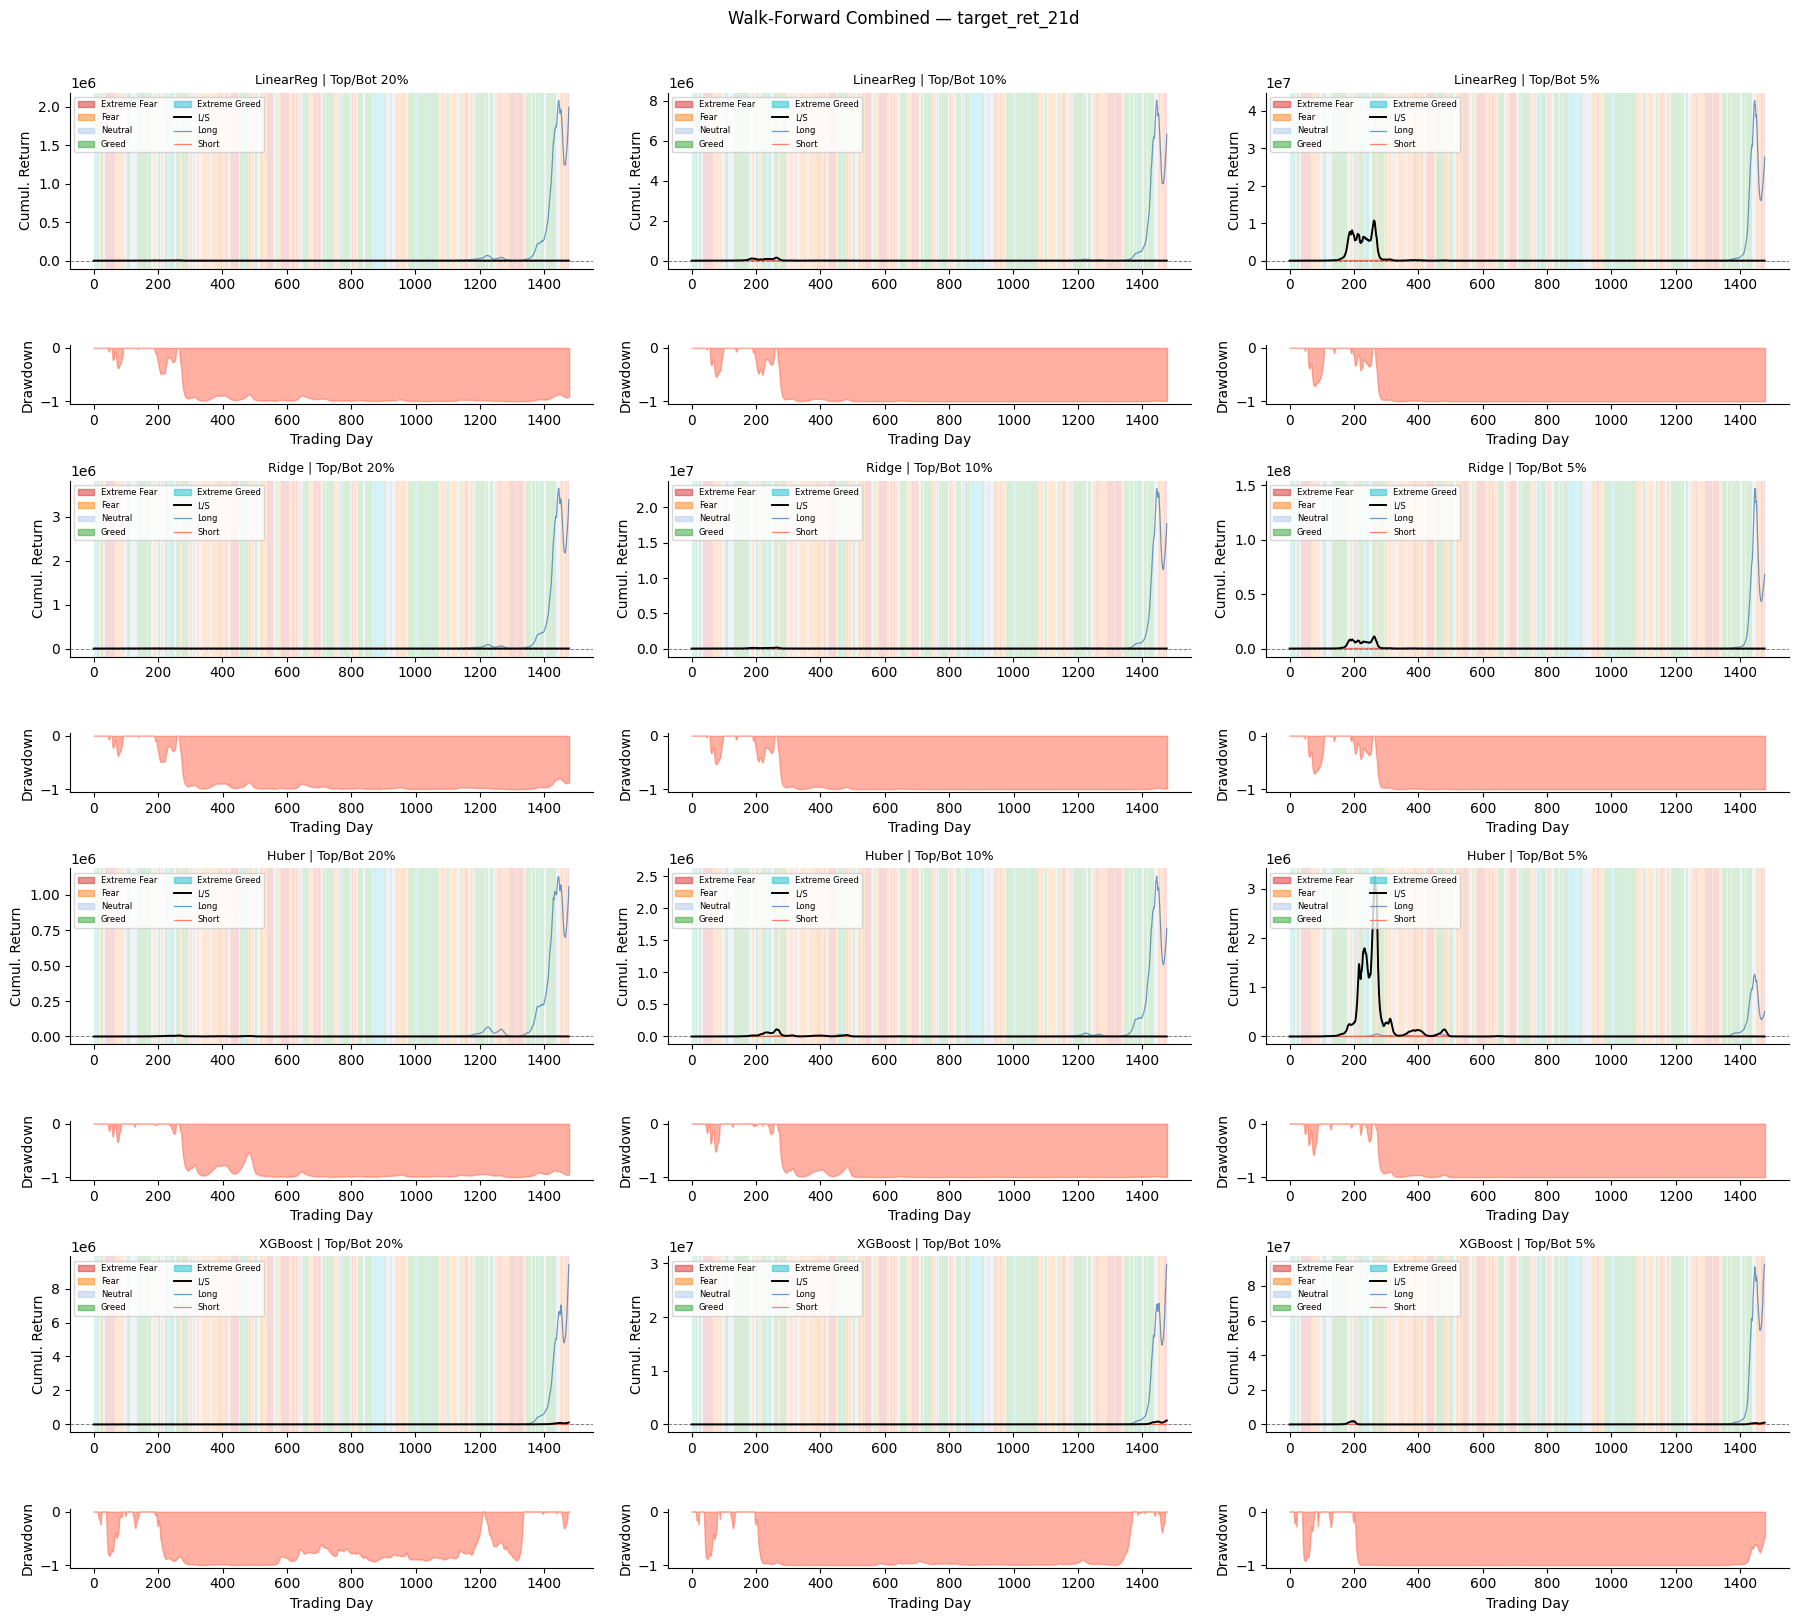

In [111]:
# ── 12d. Equity Curves — Walk-Forward Combined ────────────────────────────────
model_list = list(wf_combined.keys())
n_models   = len(model_list)
n_quants   = len(PORT_QUANTILES)

fig, axes = plt.subplots(n_models * 2, n_quants,
                         figsize=(6 * n_quants, 4 * n_models),
                         gridspec_kw={'height_ratios': [3, 1] * n_models})

for mi, model_name in enumerate(model_list):
    pred_df = wf_combined[model_name]
    dates   = sorted(pred_df['date'].unique())

    for qi, q in enumerate(PORT_QUANTILES):
        eq_ax = axes[mi * 2,     qi]
        dd_ax = axes[mi * 2 + 1, qi]

        ls_df = compute_ls_returns(pred_df, q)
        title = f'{model_name} | Top/Bot {int(q*100)}%'
        plot_equity_and_drawdown([eq_ax, dd_ax], ls_df, dates, title)

plt.suptitle(f'Walk-Forward Combined — {TARGET_COL}', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

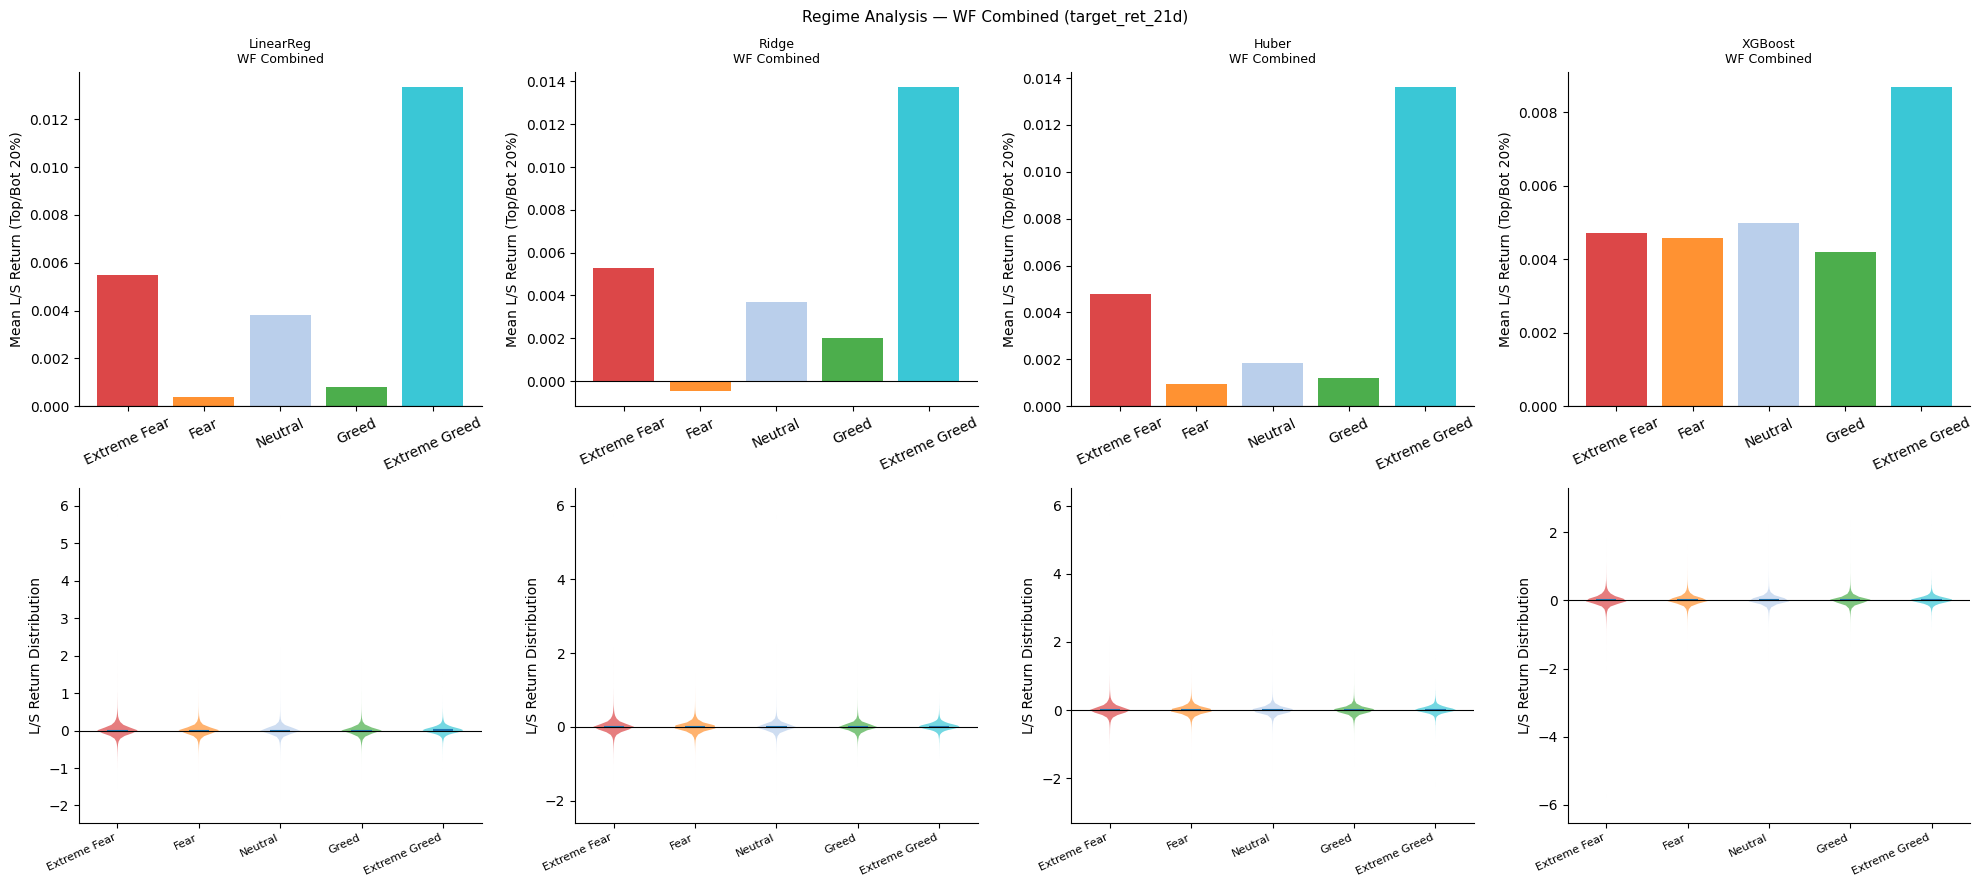

In [112]:
# ── 12g. Regime Analysis — Mean Return & Distribution ─────────────────────────
def plot_regime_analysis(preds_dict, dataset_label):
    fig, axes = plt.subplots(2, len(preds_dict),
                             figsize=(5 * len(preds_dict), 9))
    if len(preds_dict) == 1:
        axes = axes.reshape(2, 1)

    for col_i, (model_name, pred_df) in enumerate(preds_dict.items()):
        # Attach regime label to predictions
        merged = pred_df.copy()
        merged['date'] = pd.to_datetime(merged['date'])
        merged = merged.merge(
            mkt_df[['date', 'fear_greed']], on='date', how='left'
        )
        merged['fng_regime'] = pd.cut(merged['fear_greed'],
                                      bins=REGIME_BINS, labels=REGIME_ORDER)

        # L/S return using top/bot 20% per regime day
        merged['rank'] = merged.groupby('date')['y_pred'].rank(pct=True)
        q = 0.20
        merged['ls_contrib'] = np.where(
            merged['rank'] >= 1 - q, merged['y_true'],
            np.where(merged['rank'] <= q, -merged['y_true'], np.nan)
        )

        # Mean L/S return per regime
        ax_bar = axes[0][col_i]
        regime_mean = merged.groupby('fng_regime')['ls_contrib'].mean().reindex(REGIME_ORDER)
        colors = [REGIME_COLORS[r] for r in REGIME_ORDER]
        ax_bar.bar(REGIME_ORDER, regime_mean.values, color=colors, alpha=0.85)
        ax_bar.axhline(0, color='black', lw=0.8)
        ax_bar.set_title(f'{model_name}\n{dataset_label}', fontsize=9)
        ax_bar.set_ylabel('Mean L/S Return (Top/Bot 20%)')
        ax_bar.tick_params(axis='x', rotation=25)

        # Return distribution per regime (violin)
        ax_vio = axes[1][col_i]
        plot_data = [
            merged.loc[merged['fng_regime'] == r, 'ls_contrib'].dropna().values
            for r in REGIME_ORDER
        ]
        parts = ax_vio.violinplot(plot_data, positions=range(len(REGIME_ORDER)),
                                  showmedians=True, showextrema=False)
        for pc, r in zip(parts['bodies'], REGIME_ORDER):
            pc.set_facecolor(REGIME_COLORS[r])
            pc.set_alpha(0.6)
        ax_vio.axhline(0, color='black', lw=0.8)
        ax_vio.set_xticks(range(len(REGIME_ORDER)))
        ax_vio.set_xticklabels(REGIME_ORDER, rotation=25, ha='right', fontsize=8)
        ax_vio.set_ylabel('L/S Return Distribution')

    plt.suptitle(f'Regime Analysis — {dataset_label} ({TARGET_COL})', fontsize=11)
    plt.tight_layout()
    plt.show()

plot_regime_analysis(wf_combined, 'WF Combined')

In [113]:
# ── 12h. Regime-Conditional Sharpe ───────────────────────────────────────────
def regime_conditional_sharpe(preds_dict, dataset_label, quantile=0.20):
    rows = []
    for model_name, pred_df in preds_dict.items():
        merged = pred_df.copy()
        merged['date'] = pd.to_datetime(merged['date'])
        merged = merged.merge(mkt_df[['date', 'fear_greed']], on='date', how='left')
        merged['fng_regime'] = pd.cut(merged['fear_greed'],
                                      bins=REGIME_BINS, labels=REGIME_ORDER)

        for regime in REGIME_ORDER:
            sub = merged[merged['fng_regime'] == regime]
            if len(sub) < 50:
                continue
            ls_df = compute_ls_returns(sub, quantile)
            m     = compute_strategy_metrics(ls_df['ls_ret'])
            rows.append({'Model': model_name, 'Regime': regime,
                         'N days': len(sub['date'].unique()),
                         'Sharpe': m['Sharpe'],
                         'Ann. Return': m['Ann. Return']})

    tbl = pd.DataFrame(rows).pivot_table(
        index='Regime', columns='Model',
        values='Sharpe', aggfunc='mean'
    ).reindex(REGIME_ORDER)

    print(f'=== Regime-Conditional Sharpe ({dataset_label}) ===')
    print(tbl.round(3).to_string())
    return tbl

sharpe_wf = regime_conditional_sharpe(wf_combined, 'WF Combined')

=== Regime-Conditional Sharpe (WF Combined) ===
Model          Huber  LinearReg   Ridge  XGBoost
Regime                                          
Extreme Fear  0.5480     0.6520  0.6230   0.4060
Fear          0.1490     0.0670 -0.0390   0.6150
Neutral       0.2840     0.5180  0.5090   0.5690
Greed         0.2130     0.1220  0.2800   0.5670
Extreme Greed 2.9640     2.4210  2.6560   1.9970


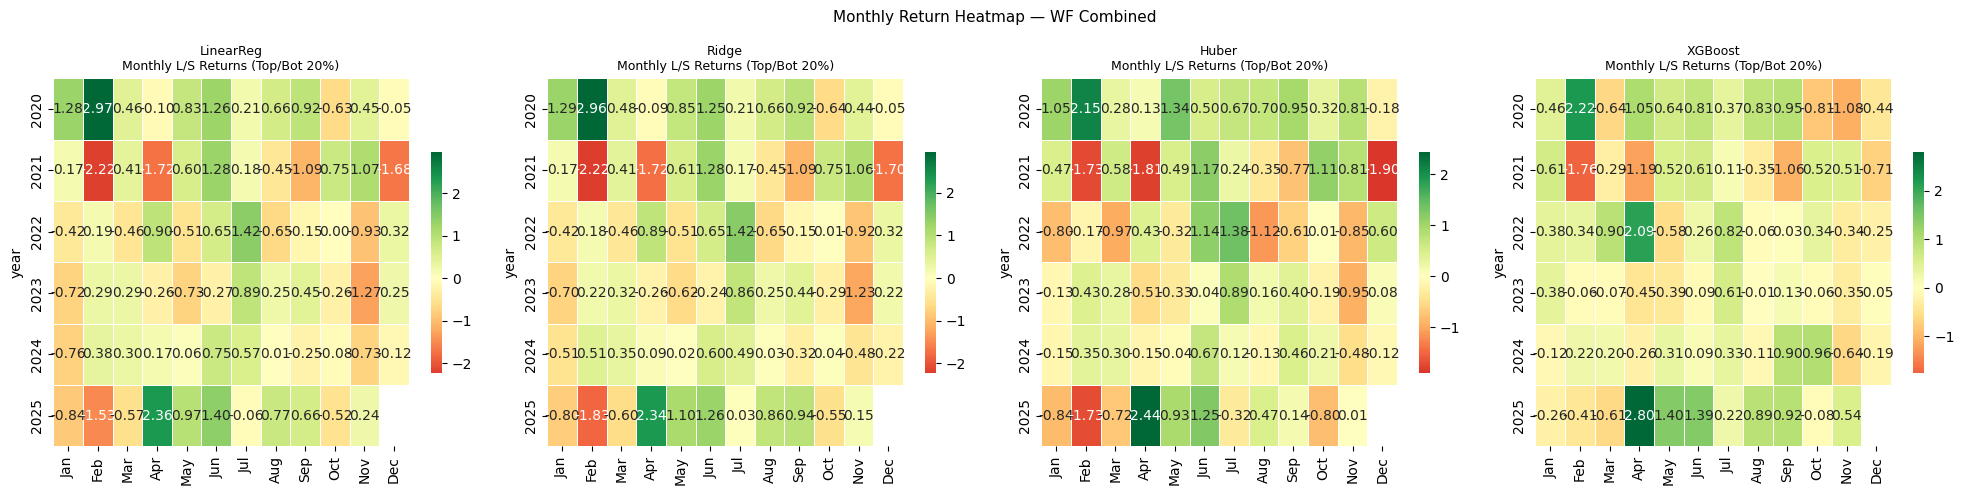

In [114]:
# ── 12i. Monthly Return Heatmap ───────────────────────────────────────────────
def plot_monthly_heatmap(preds_dict, dataset_label, quantile=0.20):
    fig, axes = plt.subplots(1, len(preds_dict),
                             figsize=(5 * len(preds_dict), 5))
    if len(preds_dict) == 1:
        axes = [axes]

    for ax, (model_name, pred_df) in zip(axes, preds_dict.items()):
        ls_df = compute_ls_returns(pred_df, quantile)
        ls_s  = ls_df['ls_ret'].copy()
        ls_s.index = pd.to_datetime(ls_s.index)

        # Monthly sum
        monthly = ls_s.resample('ME').sum()
        monthly.index = monthly.index.to_period('M')

        pivot = monthly.to_frame('ret')
        pivot['year']  = pivot.index.year
        pivot['month'] = pivot.index.month
        heat = pivot.pivot(index='year', columns='month', values='ret')
        heat.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec'][:len(heat.columns)]

        sns.heatmap(heat, ax=ax, cmap='RdYlGn', center=0,
                    annot=True, fmt='.2f', linewidths=0.4,
                    cbar_kws={'shrink': 0.6})
        ax.set_title(f'{model_name}\nMonthly L/S Returns (Top/Bot {int(quantile*100)}%)',
                     fontsize=9)

    plt.suptitle(f'Monthly Return Heatmap — {dataset_label}', fontsize=11)
    plt.tight_layout()
    plt.show()

plot_monthly_heatmap(wf_combined, 'WF Combined')

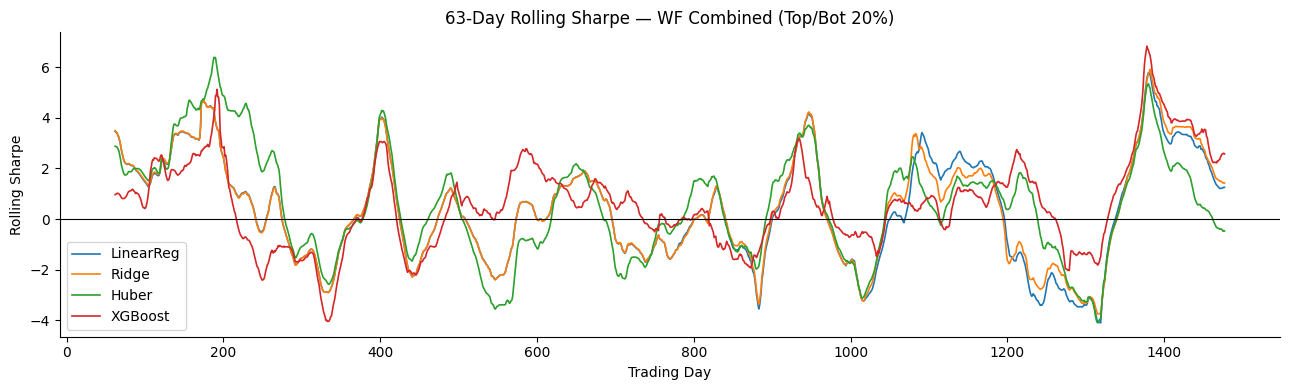

In [115]:
# ── 12j. Rolling Sharpe (63-day window) ──────────────────────────────────────
def plot_rolling_sharpe(preds_dict, dataset_label, quantile=0.20, window=63):
    fig, ax = plt.subplots(figsize=(13, 4))

    for model_name, pred_df in preds_dict.items():
        ls_s = compute_ls_returns(pred_df, quantile)['ls_ret']
        roll_sharpe = (ls_s.rolling(window).mean() /
                       ls_s.rolling(window).std()) * np.sqrt(ANN_FACTOR)
        x = np.arange(len(roll_sharpe))
        ax.plot(x, roll_sharpe.values, lw=1.2, label=model_name)

    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'{window}-Day Rolling Sharpe — {dataset_label} (Top/Bot {int(quantile*100)}%)')
    ax.set_xlabel('Trading Day')
    ax.set_ylabel('Rolling Sharpe')
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_rolling_sharpe(wf_combined, 'WF Combined')

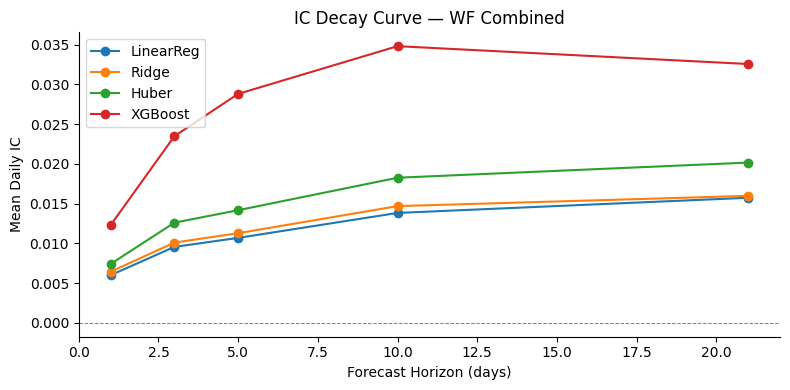

Model           Huber  LinearReg  Ridge  XGBoost
Horizon (days)                                  
1              0.0074     0.0060 0.0064   0.0123
3              0.0126     0.0096 0.0101   0.0235
5              0.0142     0.0107 0.0113   0.0288
10             0.0183     0.0138 0.0147   0.0348
21             0.0202     0.0157 0.0160   0.0326


In [116]:
# ── 12k. IC Decay Curve ───────────────────────────────────────────────────────
# Shows how IC changes across 1d, 3d, 5d, 10d, 21d horizons.
# Requires retraining against each target, so we use the WF combined test
# predictions (which predicted TARGET_COL) and correlate against shorter targets.

horizons   = ['target_ret_1d', 'target_ret_3d', 'target_ret_5d',
              'target_ret_10d', 'target_ret_21d']
horizon_days = [1, 3, 5, 10, 21]

# Load actual returns for WF test period from df
test_dates = set()
for pred_df in wf_combined.values():
    test_dates.update(pd.to_datetime(pred_df['date'].unique()).tolist())

test_actuals = (
    df[df['date'].isin(test_dates)][['date', 'ticker'] + horizons]
    .dropna()
)

ic_decay = []
for model_name, pred_df in wf_combined.items():
    merged = pred_df.merge(test_actuals, on=['date', 'ticker'], how='inner')
    for h, h_col in zip(horizon_days, horizons):
        if h_col not in merged.columns:
            continue
        daily_ic = (
            merged.groupby('date')
            .apply(lambda g: spearmanr(g['y_pred'], g[h_col])[0]
                   if len(g) >= 5 else np.nan)
            .dropna()
        )
        ic_decay.append({'Model': model_name,
                         'Horizon (days)': h,
                         'Mean IC': daily_ic.mean()})

ic_decay_df = pd.DataFrame(ic_decay)

fig, ax = plt.subplots(figsize=(8, 4))
for model_name in wf_combined:
    sub = ic_decay_df[ic_decay_df['Model'] == model_name].sort_values('Horizon (days)')
    ax.plot(sub['Horizon (days)'], sub['Mean IC'], marker='o', lw=1.5, label=model_name)
ax.axhline(0, color='gray', lw=0.7, ls='--')
ax.set_title('IC Decay Curve — WF Combined')
ax.set_xlabel('Forecast Horizon (days)')
ax.set_ylabel('Mean Daily IC')
ax.legend()
plt.tight_layout()
plt.show()

print(ic_decay_df.pivot(index='Horizon (days)', columns='Model', values='Mean IC').round(4).to_string())

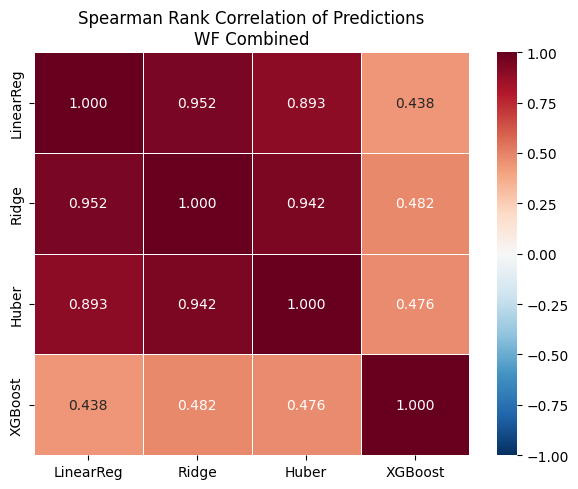

In [117]:
# ── 12l. Model Prediction Correlation Matrix ──────────────────────────────────
def plot_pred_correlation(preds_dict, dataset_label):
    # Align all predictions by (date, ticker)
    dfs = []
    for model_name, pred_df in preds_dict.items():
        dfs.append(pred_df[['date', 'ticker', 'y_pred']].rename(
            columns={'y_pred': model_name}))

    merged = dfs[0]
    for d in dfs[1:]:
        merged = merged.merge(d, on=['date', 'ticker'], how='inner')

    corr = merged[list(preds_dict.keys())].corr(method='spearman')

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
    ax.set_title(f'Spearman Rank Correlation of Predictions\n{dataset_label}')
    plt.tight_layout()
    plt.show()

plot_pred_correlation(wf_combined, 'WF Combined')

In [118]:
# ── 12m. XGBoost Feature Importance & Linear Model Coefficients ───────────────
# Skipped when USE_PCA=True (PCA components don't map back to original feature names)
if USE_PCA:
    print('Feature importance / coefficient plots skipped (USE_PCA=True).')
elif xgb_imps:
    imp_mean = pd.DataFrame(xgb_imps).mean(axis=1).sort_values(ascending=False)
    top_n = 20
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(imp_mean.index[:top_n][::-1], imp_mean.values[:top_n][::-1],
            color='steelblue', alpha=0.85)
    ax.set_title(f'XGBoost Mean Feature Importance (top {top_n}, WF avg)')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

# Mean absolute coefficient magnitude for linear models
lin_model_names = ['LinearReg', 'Ridge', 'Huber']
coef_rows = {}
for fold_name, fold_coefs in lin_coefs.items():
    for model_name, coef_arr in fold_coefs.items():
        if model_name not in coef_rows:
            coef_rows[model_name] = []
        coef_rows[model_name].append(np.abs(coef_arr))

if coef_rows:
    fig, axes = plt.subplots(1, len(coef_rows), figsize=(7 * len(coef_rows), 5))
    if len(coef_rows) == 1:
        axes = [axes]
    for ax, (model_name, coef_list) in zip(axes, coef_rows.items()):
        mean_abs = pd.Series(np.stack(coef_list).mean(axis=0), index=FEATURE_COLS)
        mean_abs = mean_abs.sort_values(ascending=False).head(20)
        ax.barh(mean_abs.index[::-1], mean_abs.values[::-1], color='steelblue', alpha=0.85)
        ax.set_title(f'{model_name}: Mean |Coefficient| (top 20, WF avg)')
        ax.set_xlabel('Mean |Coef|')
    plt.tight_layout()
    plt.show()

Feature importance / coefficient plots skipped (USE_PCA=True).


## 13. Final Scorecard

In [119]:
# ── 13. Final Scorecard ───────────────────────────────────────────────────────
print(f'\n{"="*70}')
print(f'FINAL SCORECARD — Target: {TARGET_COL}')
print(f'{"="*70}')

print('\n--- Walk-Forward Average IC by Model ---')
wf_df = pd.DataFrame(wf_results)
print(wf_df.groupby('Model')[['Mean Daily IC', 'ICIR', 'Hit Rate', 'R2']].mean().round(4).to_string())

print('\n--- L/S Sharpe by Model (Walk-Forward, Top/Bot 20%) ---')
sharpe_pivot = (
    strat_all[strat_all['Quantile'] == 'Top/Bot 20%']
    .pivot_table(index='Model', columns='Dataset', values='Sharpe')
)
print(sharpe_pivot.round(3).to_string())

print('\n--- Full Strategy Metrics (Walk-Forward Combined) ---')
print(
    strat_wf.set_index(['Model', 'Quantile'])[metric_cols]
    .round(3).to_string()
)



FINAL SCORECARD — Target: target_ret_21d

--- Walk-Forward Average IC by Model ---
           Mean Daily IC   ICIR  Hit Rate      R2
Model                                            
Huber             0.0200 0.1796    0.5446 -0.0188
LinearReg         0.0161 0.1216    0.5464 -0.0413
Ridge             0.0163 0.1225    0.5431 -0.0522
XGBoost           0.0338 0.1934    0.5357 -0.0961

--- L/S Sharpe by Model (Walk-Forward, Top/Bot 20%) ---
Dataset    WF Combined
Model                 
Huber           0.3630
LinearReg       0.3590
Ridge           0.3740
XGBoost         0.5890

--- Full Strategy Metrics (Walk-Forward Combined) ---
                       Ann. Return  Ann. Vol  Sharpe  Sortino  Calmar  Max DD  Win Rate
Model     Quantile                                                                     
LinearReg Top/Bot 20%       0.0650    0.1810  0.3590   0.6010  0.0650 -1.0000    0.5490
          Top/Bot 10%       0.0850    0.2400  0.3530   0.6100  0.0850 -1.0000    0.5390
          Top/